# Fig 5c - fourth-round Systema Correlation across methods and acquisition strategies

Each point represents one context and repeat. The x-axis compares methods, with acquisition strategies shown as grouped bars at the fourth active-learning round.

In [11]:
# Cell 1 - imports, style, and export helper
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "font.size": 8,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.7,
    "legend.frameon": False,
})


def save_pub_py(fig, stem, dpi=600):
    """Save a figure as editable SVG and raster PNG.

    Args:
        fig: Matplotlib figure to save.
        stem: Output path without a file extension.
        dpi: Resolution of the PNG export.
    """
    Path(stem).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{stem}.svg", bbox_inches="tight")
    fig.savefig(f"{stem}.png", dpi=dpi, bbox_inches="tight")
    print(f"saved -> {stem}.svg / {stem}.png")

In [16]:
# Cell 2 - parameters (edit this cell)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "results").is_dir():
    REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd()
RESULTS_DIR = REPO_ROOT / "results" / "active_learning"
OUT_STEM = REPO_ROOT / "figure" / "fig5c" / "fig5g_fourth_round_acquisition_scatter"

METHODS = ["Biolord", "PRESAGE", "scLambda", "GenePert"]
CONTEXTS = [
    "replogle_rpe1_essential_rpe1",
    "replogle_k562_essential_k562",
    "nadig_jurkat_essential_jurkat",
    "nadig_hepg2_essential_hepg2",
]
CONTEXT_LABELS = {
    "replogle_rpe1_essential_rpe1": "RPE1",
    "replogle_k562_essential_k562": "K562",
    "nadig_jurkat_essential_jurkat": "Jurkat",
    "nadig_hepg2_essential_hepg2": "HepG2",
}

SEED_REP = "56_3"
REPEATS = [0, 1, 2]
METRIC = "systema_correlation"
GENE = "all"
SET_NAME = "test"
ROUND_BUDGET = 80

STRATEGIES = [
    "random_sampling",
    "diversity_sampling",
    "representative_sampling",
    "magnitude_sampling",
    "outlier_sampling",
    "typical_sampling",
]
STRATEGY_LABELS = {
    "random_sampling": "Random",
    "diversity_sampling": "Diversity",
    "representative_sampling": "Representative",
    "magnitude_sampling": "Magnitude",
    "outlier_sampling": "Outlier",
    "typical_sampling": "Typical",
}
STRATEGY_COLORS = {
    "random_sampling": "#7F7F7F",
    "diversity_sampling": "#F04438",
    "representative_sampling": "#B2182B",
    "magnitude_sampling": "#4393C3",
    "outlier_sampling": "#2166AC",
    "typical_sampling": "#053061",
}

FIGSIZE = (4, 6)
JITTER_WIDTH = 0.055
BAR_WIDTH = 0.12
POINT_SIZE = 24
POINT_ALPHA = 0.88
Y_LIM = (0.0, 0.65)
Y_TICKS = [0.0, 0.2, 0.4, 0.6]
SHOW_LEGEND = True

In [17]:
# Cell 3 - load fourth-round points
def load_points():
    """Load one PCC specificity value for every context/repeat point.

    Returns:
        DataFrame with method, context, repeat, strategy, and value columns.
    """
    rows = []
    for method in METHODS:
        for context in CONTEXTS:
            for strategy in STRATEGIES:
                path = RESULTS_DIR / context / method / f"{strategy}_{SEED_REP}" / "achievement_summary_rebuilt.csv"
                frame = pd.read_csv(path)
                selected = frame[
                    (frame["metric_name"] == METRIC)
                    & (frame["gene"] == GENE)
                    & (frame["set"] == SET_NAME)
                    & (frame["x"].sub(ROUND_BUDGET).abs() <= max(0.3, 0.15 * ROUND_BUDGET))
                    & (frame["repeat"].isin(REPEATS))
                ]
                for _, row in selected.iterrows():
                    rows.append({
                        "method": method,
                        "context": context,
                        "repeat": int(row["repeat"]),
                        "strategy": strategy,
                        "value": float(row["value"]),
                    })
    points = pd.DataFrame(rows)
    expected = len(METHODS) * len(CONTEXTS) * len(STRATEGIES) * len(REPEATS)
    if len(points) != expected:
        raise ValueError(f"Expected {expected} points, found {len(points)}.")
    return points


points = load_points()
print(points.groupby(["method", "strategy"]).size().unstack(fill_value=0))

strategy  diversity_sampling  magnitude_sampling  outlier_sampling  \
method                                                               
Biolord                   12                  12                12   
GenePert                  12                  12                12   
PRESAGE                   12                  12                12   
scLambda                  12                  12                12   

strategy  random_sampling  representative_sampling  typical_sampling  
method                                                                
Biolord                12                       12                12  
GenePert               12                       12                12  
PRESAGE                12                       12                12  
scLambda               12                       12                12  


saved -> figures/fig5g_fourth_round_acquisition_scatter.svg / figures/fig5g_fourth_round_acquisition_scatter.png


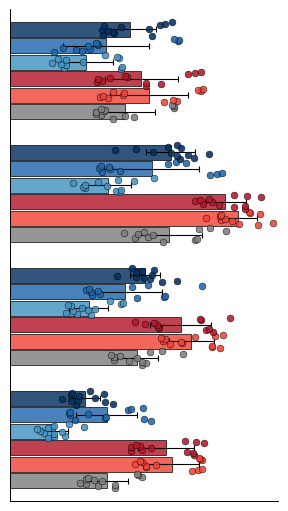

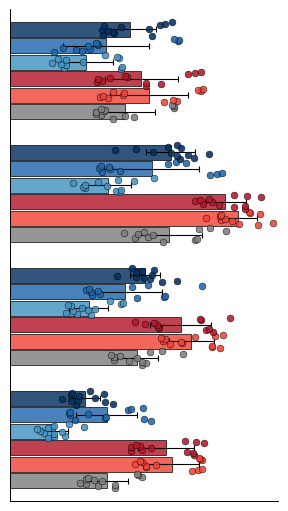

In [18]:
# Cell 4 - draw one grouped method comparison
def draw_grouped_comparison(axis):
    """Draw acquisition strategies grouped by method.

    Args:
        axis: Matplotlib axis on which to draw the comparison.
    """
    method_positions = np.arange(len(METHODS), dtype=float)
    offsets = (np.arange(len(STRATEGIES)) - (len(STRATEGIES) - 1) / 2) * (BAR_WIDTH * 1.12)
    for strategy_index, strategy in enumerate(STRATEGIES):
        for method_index, method in enumerate(METHODS):
            strategy_points = points[(points["method"] == method) & (points["strategy"] == strategy)]
            values = strategy_points["value"].to_numpy(float)
            axis.barh(
                method_positions[method_index] + offsets[strategy_index], values.mean(),
                height=BAR_WIDTH, color=STRATEGY_COLORS[strategy], alpha=0.82,
                edgecolor="black", linewidth=0.6, xerr=values.std(ddof=0),
                error_kw=dict(ecolor="black", lw=0.8, capsize=2.0, capthick=0.8), zorder=1,
            )
            jitter = np.linspace(-JITTER_WIDTH, JITTER_WIDTH, len(values))
            axis.scatter(
                values, method_positions[method_index] + offsets[strategy_index] + jitter,
                s=POINT_SIZE, color=STRATEGY_COLORS[strategy], alpha=POINT_ALPHA,
                edgecolors="black", linewidths=0.35, zorder=3,
            )
    axis.set_xlim(*Y_LIM)
    axis.set_ylim(-0.5, len(METHODS) - 0.5)
    axis.set_xticks(Y_TICKS)
    axis.grid(True, axis="x", alpha=0.2, linewidth=0.5, zorder=0)
    axis.set_axisbelow(True)
    axis.tick_params(length=2.5, width=0.6, labelsize=8, labelbottom=True, labelleft=True)
    axis.set_yticks(method_positions)
    axis.set_yticklabels(METHODS, fontsize=8)
    axis.set_xlabel("Systema Correlation", fontsize=9)
    axis.set_ylabel("Method", fontsize=9)
    axis.legend([], [], frameon=False)


fig, axis = plt.subplots(figsize=FIGSIZE)
draw_grouped_comparison(axis)
fig.subplots_adjust(left=0.12, right=0.79, top=0.98, bottom=0.16)
save_pub_py(fig, OUT_STEM)
fig

In [19]:
# Cell 5 - context-paired one-sided tests against random acquisition
def run_paired_tests():
    """Test whether repeat-averaged diversity or representative exceeds random.

    Returns:
        DataFrame with raw and Holm-adjusted one-sided Wilcoxon p-values.
    """
    rows = []
    for method in METHODS:
        subset = points[points["method"] == method]
        random_values = (subset[subset["strategy"] == "random_sampling"]
                         .groupby("context")["value"].mean())
        for strategy in ["diversity_sampling", "representative_sampling"]:
            tested = (subset[subset["strategy"] == strategy]
                      .groupby("context")["value"].mean()
                      .reindex(random_values.index))
            differences = tested - random_values
            statistic, p_value = wilcoxon(differences, alternative="greater", method="auto")
            rows.append({
                "method": method,
                "comparison": f"{STRATEGY_LABELS[strategy]} vs Random",
                "n_pairs": len(differences),
                "median_difference": differences.median(),
                "statistic": statistic,
                "p_value": p_value,
            })
    results = pd.DataFrame(rows)
    results["p_holm"] = multipletests(results["p_value"], method="holm")[1]
    results["significant_0.05"] = results["p_holm"] < 0.05
    return results.sort_values(["method", "comparison"]).reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
test_results = run_paired_tests()
print(test_results.to_string(index=False, float_format=lambda value: f"{value:.4g}"))

  method               comparison  n_pairs  median_difference  statistic  p_value  p_holm  significant_0.05
 Biolord      Diversity vs Random        4            0.05316         10   0.0625     0.5             False
 Biolord Representative vs Random        4            0.04639         10   0.0625     0.5             False
GenePert      Diversity vs Random        4             0.1469         10   0.0625     0.5             False
GenePert Representative vs Random        4             0.1305         10   0.0625     0.5             False
 PRESAGE      Diversity vs Random        4             0.1842         10   0.0625     0.5             False
 PRESAGE Representative vs Random        4             0.1482         10   0.0625     0.5             False
scLambda      Diversity vs Random        4             0.1205         10   0.0625     0.5             False
scLambda Representative vs Random        4            0.09338         10   0.0625     0.5             False
